In [1]:
!pip install open_clip_torch

In [2]:
# ============================================================
# Publication-Ready Few-Shot Brain Tumor Classification
# Fixes Applied:
# 1. Proper train/test split isolation (no leakage)
# 2. 95% Confidence Intervals via bootstrapping
# 3. 600 evaluation episodes (standard in FSL literature)
# 4. McNemar statistical significance test between models
# 5. EfficientNet neck removed (clean backbone comparison)
# 6. Per-class metrics clearly reported
# 7. Dataset split reported separately (not pooled)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import random
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
import open_clip
import hashlib


In [3]:
# ========================= KAGGLE VISUALIZATION FIX =========================
from IPython.display import display, Image as IPImage
import matplotlib
matplotlib.use('Agg')   # Must be BEFORE importing pyplot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec   # (kept in case needed later)

# Helper: save + immediately display in Kaggle
def save_and_display(fig, filename, dpi=200):
    filepath = f"/kaggle/working/{filename}"
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    display(IPImage(filepath))
    print(f"  ✓ Saved and displayed: {filepath}")
    return filepath

In [4]:
# ========================= CONFIG =========================
IMAGE_SIZE = 224
N_WAY = 4
SHOTS = [1, 5, 10]
EPISODES_EVAL = 600

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

CI_ALPHA = 0.05
BOOTSTRAP_N = 1000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"\nFew-Shot Setup | Device: {DEVICE}")
print(f"Episodes: {EPISODES_EVAL} | CI: {int((1-CI_ALPHA)*100)}%")




Few-Shot Setup | Device: cuda
Episodes: 600 | CI: 95%


In [5]:
# ========================= DATASET 1 ONLY (NO MERGING) =========================

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
N_WAY = 4

print("\n📦 Using SINGLE dataset only (Dataset 1)")
print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)


📦 Using SINGLE dataset only (Dataset 1)
Train: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Test : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [6]:
# ========================= LOAD DATA =========================
def load_classwise_split(root):
    classwise = {i: [] for i in range(N_WAY)}

    for i, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(root, cls)
        if os.path.exists(cls_dir):
            classwise[i] = [
                os.path.join(cls_dir, f)
                for f in os.listdir(cls_dir)
            ]

    return classwise


support_pool = load_classwise_split(TRAIN_DIR)
query_pool   = load_classwise_split(TEST_DIR)

print("\nDataset Distribution:")
print("Support:", [len(support_pool[i]) for i in range(N_WAY)])
print("Query  :", [len(query_pool[i]) for i in range(N_WAY)])




Dataset Distribution:
Support: [1400, 1400, 1400, 1400]
Query  : [400, 400, 400, 400]


In [7]:

# ========================= DUPLICATE REMOVAL =========================
def hash_image(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def remove_duplicates(pool):
    cleaned = {}
    removed = 0

    for cls, paths in pool.items():
        seen = set()   # ✔ reset per class (IMPORTANT FIX)
        new_list = []

        for p in paths:
            h = hash_image(p)
            if h not in seen:
                seen.add(h)
                new_list.append(p)
            else:
                removed += 1

        cleaned[cls] = new_list

    return cleaned, removed

print("\n🔧 Removing duplicates...")
support_pool, r1 = remove_duplicates(support_pool)
query_pool, r2   = remove_duplicates(query_pool)

print(f"Removed TRAIN duplicates: {r1}")
print(f"Removed TEST duplicates: {r2}")

# ========================= LEAKAGE CHECK =========================
print("\n================ LEAKAGE CHECK ================")

train_paths = set(sum(support_pool.values(), []))
test_paths  = set(sum(query_pool.values(), []))

overlap = train_paths.intersection(test_paths)

train_hashes = {hash_image(p) for p in train_paths}
test_hashes  = {hash_image(p) for p in test_paths}

dup = train_hashes.intersection(test_hashes)

print("Train-Test overlap:", len(overlap))
print("Exact duplicate images:", len(dup))

assert len(overlap) == 0, "Leakage detected!"
assert len(dup) == 0, "Duplicate leakage detected!"

print("✅ PASS: No leakage detected")



🔧 Removing duplicates...
Removed TRAIN duplicates: 171
Removed TEST duplicates: 16

================ LEAKAGE CHECK ================
Train-Test overlap: 0
Exact duplicate images: 0
✅ PASS: No leakage detected


In [8]:
# ========================= SUMMARY =========================
print("\n================ FINAL DATASET STATS ================")
print("Support samples:", sum(len(v) for v in support_pool.values()))
print("Query samples  :", sum(len(v) for v in query_pool.values()))
print("Classes        :", CLASS_NAMES)


================ FINAL DATASET STATS ================
Support samples: 5429
Query samples  : 1584
Classes        : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
# ========================= EPISODE CREATION (Leak-Free) =========================
def create_episode(k_shot, support_classwise, query_classwise, query_per_class=15):
    support_paths, query_paths = [], []
    support_labels, query_labels = [], []
    for cls_idx in range(N_WAY):
        s_imgs = support_classwise[cls_idx]
        if len(s_imgs) < k_shot:
            s_sel = random.choices(s_imgs, k=k_shot)
        else:
            s_sel = random.sample(s_imgs, k_shot)
        
        q_imgs = query_classwise[cls_idx]
        if len(q_imgs) < query_per_class:
            q_sel = random.choices(q_imgs, k=query_per_class)
        else:
            q_sel = random.sample(q_imgs, query_per_class)
        
        support_paths.extend(s_sel)
        query_paths.extend(q_sel)
        support_labels.extend([cls_idx] * k_shot)
        query_labels.extend([cls_idx] * query_per_class)
    
    return (
        support_paths,
        query_paths,
        torch.tensor(support_labels, dtype=torch.long),
        torch.tensor(query_labels, dtype=torch.long)
    )

In [10]:
# ========================= MODELS =========================
print("Loading models...")
biomed_model, biomed_preprocess = open_clip.create_model_from_pretrained(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
biomed_visual = biomed_model.visual.to(DEVICE)
biomed_visual.eval()

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE)
resnet.eval()

efficientnet = models.efficientnet_b0(pretrained=True)
efficientnet.classifier = nn.Identity()
efficientnet = efficientnet.to(DEVICE)
efficientnet.eval()

imagenet_preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model_configs = {
    "BioMedCLIP": {"encoder": biomed_visual, "preprocess": biomed_preprocess, "dim": 768},
    "ResNet18": {"encoder": resnet, "preprocess": imagenet_preprocess, "dim": 512},
    "EfficientNet-B0": {"encoder": efficientnet, "preprocess": imagenet_preprocess, "dim": 1280}
}
print("✅ Models loaded.\n")

Loading models...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most u

✅ Models loaded.



In [11]:
import shutil

cache_dir = "/kaggle/working/feature_cache_pub"

if os.path.exists(cache_dir):
    print("⚠️ Clearing old feature cache (dataset changed)...")
    shutil.rmtree(cache_dir)

os.makedirs(cache_dir, exist_ok=True)

⚠️ Clearing old feature cache (dataset changed)...


In [12]:
# ========================= FEATURE CACHING =========================
# (Your original caching code - unchanged)
cache_dir = "/kaggle/working/feature_cache_pub"
os.makedirs(cache_dir, exist_ok=True)

def extract_features(name, encoder, preprocess, classwise_dict, tag):
    cache_file = os.path.join(cache_dir, f"{name}_{tag}.pt")
    if os.path.exists(cache_file):
        print(f" ✓ Cached [{tag}] {name}")
        return torch.load(cache_file, map_location='cpu')
    all_paths = [p for paths in classwise_dict.values() for p in paths]
    features = {}
    with torch.no_grad():
        for path in tqdm(all_paths, desc=f"{name}[{tag}]"):
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img).unsqueeze(0).to(DEVICE)
                feat = encoder(tensor).squeeze(0).cpu()
                features[path] = feat
            except Exception as e:
                print(f" ⚠ Skipped {path}: {e}")
    torch.save(features, cache_file)
    return features

print("Pre-extracting features...")
support_feats = {}
query_feats = {}
for name, cfg in model_configs.items():
    support_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], support_pool, "train")
    query_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], query_pool, "test")
print("✅ Feature extraction done.\n")

Pre-extracting features...


EfficientNet-B0[test]: 100%|██████████| 1584/1584 [00:19<00:00, 81.80it/s]


✅ Feature extraction done.



In [20]:
# ========================= 95% CONFIDENCE INTERVAL =========================
def bootstrap_ci(acc_list, n=BOOTSTRAP_N, alpha=CI_ALPHA):
    arr = np.array(acc_list)
    samples = np.random.choice(arr, size=(n, len(arr)), replace=True).mean(axis=1)
    lo = np.percentile(samples, 100 * alpha / 2)
    hi = np.percentile(samples, 100 * (1 - alpha / 2))
    return lo, hi

In [21]:
import os

SAVE_DIR = "/kaggle/working/visualization_figure"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📁 Saving all outputs to: {SAVE_DIR}")

📁 Saving all outputs to: /kaggle/working/visualization_figure


In [22]:
# ========================= CONFUSION MATRIX PLOTTER =========================
def plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray', ax=ax
    )
    ax.set_title(
        f'{name} – {k_shot}-shot\n'
        f'Acc: {mean_acc:.3f} ± {std_acc:.3f}   |   95% CI [{ci_lo:.3f}, {ci_hi:.3f}]',
        fontsize=13, fontweight='bold', pad=14
    )
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    save_and_display(fig, f"cm_{name}_{k_shot}shot_pub.png")

In [23]:
# ========================= SUMMARY VISUALIZATIONS =========================
def plot_summary_chart(results, shots, model_names):
    n_shots = len(shots)
    n_models = len(model_names)
    x = np.arange(n_models)
    width = 0.25
    fig, axes = plt.subplots(1, n_shots, figsize=(6 * n_shots, 5), sharey=True)
    if n_shots == 1:
        axes = [axes]
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    for ax, k in zip(axes, shots):
        accs = [results[f"{m}_{k}shot"]['mean_acc'] for m in model_names]
        f1s  = [results[f"{m}_{k}shot"]['macro_f1'] for m in model_names]
        cis  = [(results[f"{m}_{k}shot"]['mean_acc'] - results[f"{m}_{k}shot"]['ci_lo'],
                 results[f"{m}_{k}shot"]['ci_hi'] - results[f"{m}_{k}shot"]['mean_acc'])
                for m in model_names]
        ci_arr = np.array(cis).T

        ax.bar(x - width/2, accs, width, label='Accuracy', color=colors, alpha=0.85,
               yerr=ci_arr, capsize=5, error_kw={'elinewidth':1.5})
        ax.bar(x + width/2, f1s, width, label='Macro-F1', color=colors, alpha=0.45, hatch='//')

        for bar in ax.patches[:len(accs)]:   # rough value labels
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{k}-Shot', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    fig.suptitle('Few-Shot Brain Tumor Classification\n(Pure Prototypical | Leak-Free | 95% CI)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_and_display(fig, "summary_accuracy_f1.png", dpi=200)

def plot_perclass_heatmap(results, shots, model_names):
    row_labels = [f"{m}\n({k}-shot)" for k in shots for m in model_names]
    data = np.array([results[f"{m}_{k}shot"]['per_class_f1'] for k in shots for m in model_names])

    fig, ax = plt.subplots(figsize=(8, max(5, len(row_labels) * 0.55 + 1.5)))
    sns.heatmap(data, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=row_labels,
                vmin=0, vmax=1, linewidths=0.4, linecolor='white', ax=ax)
    ax.set_title('Per-Class F1 Score (all models × shots)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Model / Shot')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save_and_display(fig, "perclass_f1_heatmap.png", dpi=200)

def plot_shot_progression(results, shots, model_names):
    fig, ax = plt.subplots(figsize=(8, 5))
    markers = ['o', 's', '^']
    colors = ['#1565C0', '#2E7D32', '#E65100']

    for i, name in enumerate(model_names):
        accs = [results[f"{name}_{k}shot"]['mean_acc'] for k in shots]
        ci_lo = [results[f"{name}_{k}shot"]['ci_lo'] for k in shots]
        ci_hi = [results[f"{name}_{k}shot"]['ci_hi'] for k in shots]
        ax.plot(shots, accs, marker=markers[i], color=colors[i], linewidth=2,
                markersize=8, label=name)
        ax.fill_between(shots, ci_lo, ci_hi, color=colors[i], alpha=0.12)

    ax.set_xlabel('Number of Shots (k)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Accuracy vs. Number of Shots (shaded = 95% CI)', fontsize=13, fontweight='bold')
    ax.set_xticks(shots)
    ax.set_xticklabels([f'{k}-shot' for k in shots])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    save_and_display(fig, "shot_progression.png", dpi=200)

In [24]:
# ========================= UPDATED run_fewshot =========================
def run_fewshot(k_shot, name):
    print(f"\n{'='*90}")
    print(f"  {k_shot}-SHOT | {name}  (Pure Prototypical | Leak-Free)")
    print(f"{'='*90}")

    s_feats = support_feats[name]
    q_feats = query_feats[name]
    all_true, all_pred = [], []
    episode_preds = []
    accs = []

    for ep in tqdm(range(EPISODES_EVAL), desc=f"{k_shot}-shot {name}"):
        supp_paths, qry_paths, sy, qy = create_episode(
            k_shot, support_pool, query_pool, query_per_class=15
        )
        sy, qy = sy.to(DEVICE), qy.to(DEVICE)

        sf = torch.stack([s_feats[p] for p in supp_paths]).to(DEVICE)
        qf = torch.stack([q_feats[p] for p in qry_paths]).to(DEVICE)

        sf = F.normalize(sf, p=2, dim=-1)
        qf = F.normalize(qf, p=2, dim=-1)

        prototypes = torch.stack([sf[sy == i].mean(dim=0) for i in range(N_WAY)])
        dists = 1 - torch.mm(qf, prototypes.t())
        preds = dists.argmin(dim=1)

        ep_true = qy.cpu().numpy()
        ep_pred = preds.cpu().numpy()

        all_true.extend(ep_true)
        all_pred.extend(ep_pred)
        episode_preds.append(ep_pred)
        accs.append(accuracy_score(ep_true, ep_pred))

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    ci_lo, ci_hi = bootstrap_ci(accs)

    precision, recall, f1, sup = precision_recall_fscore_support(
        all_true, all_pred, average=None, zero_division=0, labels=list(range(N_WAY))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(all_true, all_pred)

    print(f"\n  Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  95% CI    : [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Macro F1  : {macro_f1:.4f} | Precision: {macro_p:.4f} | Recall: {macro_r:.4f}")
    print(f"\n  Per-class metrics:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:12} | P: {precision[i]:.3f} | R: {recall[i]:.3f} | F1: {f1[i]:.3f} | N: {sup[i]}")

    # Plot confusion matrix with inline display
    plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi)

    return {
        'mean_acc': mean_acc, 'std_acc': std_acc,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'macro_f1': macro_f1, 'macro_p': macro_p, 'macro_r': macro_r,
        'per_class_f1': f1,
        'all_true': all_true, 'all_pred': all_pred,
        'episode_preds': episode_preds
    }


##########################################################################################
 PUBLICATION-READY FEW-SHOT EXPERIMENTS (Leak-Free | 600 Episodes | 95% CI)
##########################################################################################


  1-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


1-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 616.52it/s]



  Accuracy  : 0.5891 ± 0.0969
  95% CI    : [0.5815, 0.5966]
  Macro F1  : 0.5917 | Precision: 0.5961 | Recall: 0.5891

  Per-class metrics:
    glioma       | P: 0.447 | R: 0.466 | F1: 0.456 | N: 9000
    meningioma   | P: 0.467 | R: 0.443 | F1: 0.455 | N: 9000
    notumor      | P: 0.898 | R: 0.821 | F1: 0.858 | N: 9000
    pituitary    | P: 0.572 | R: 0.626 | F1: 0.598 | N: 9000


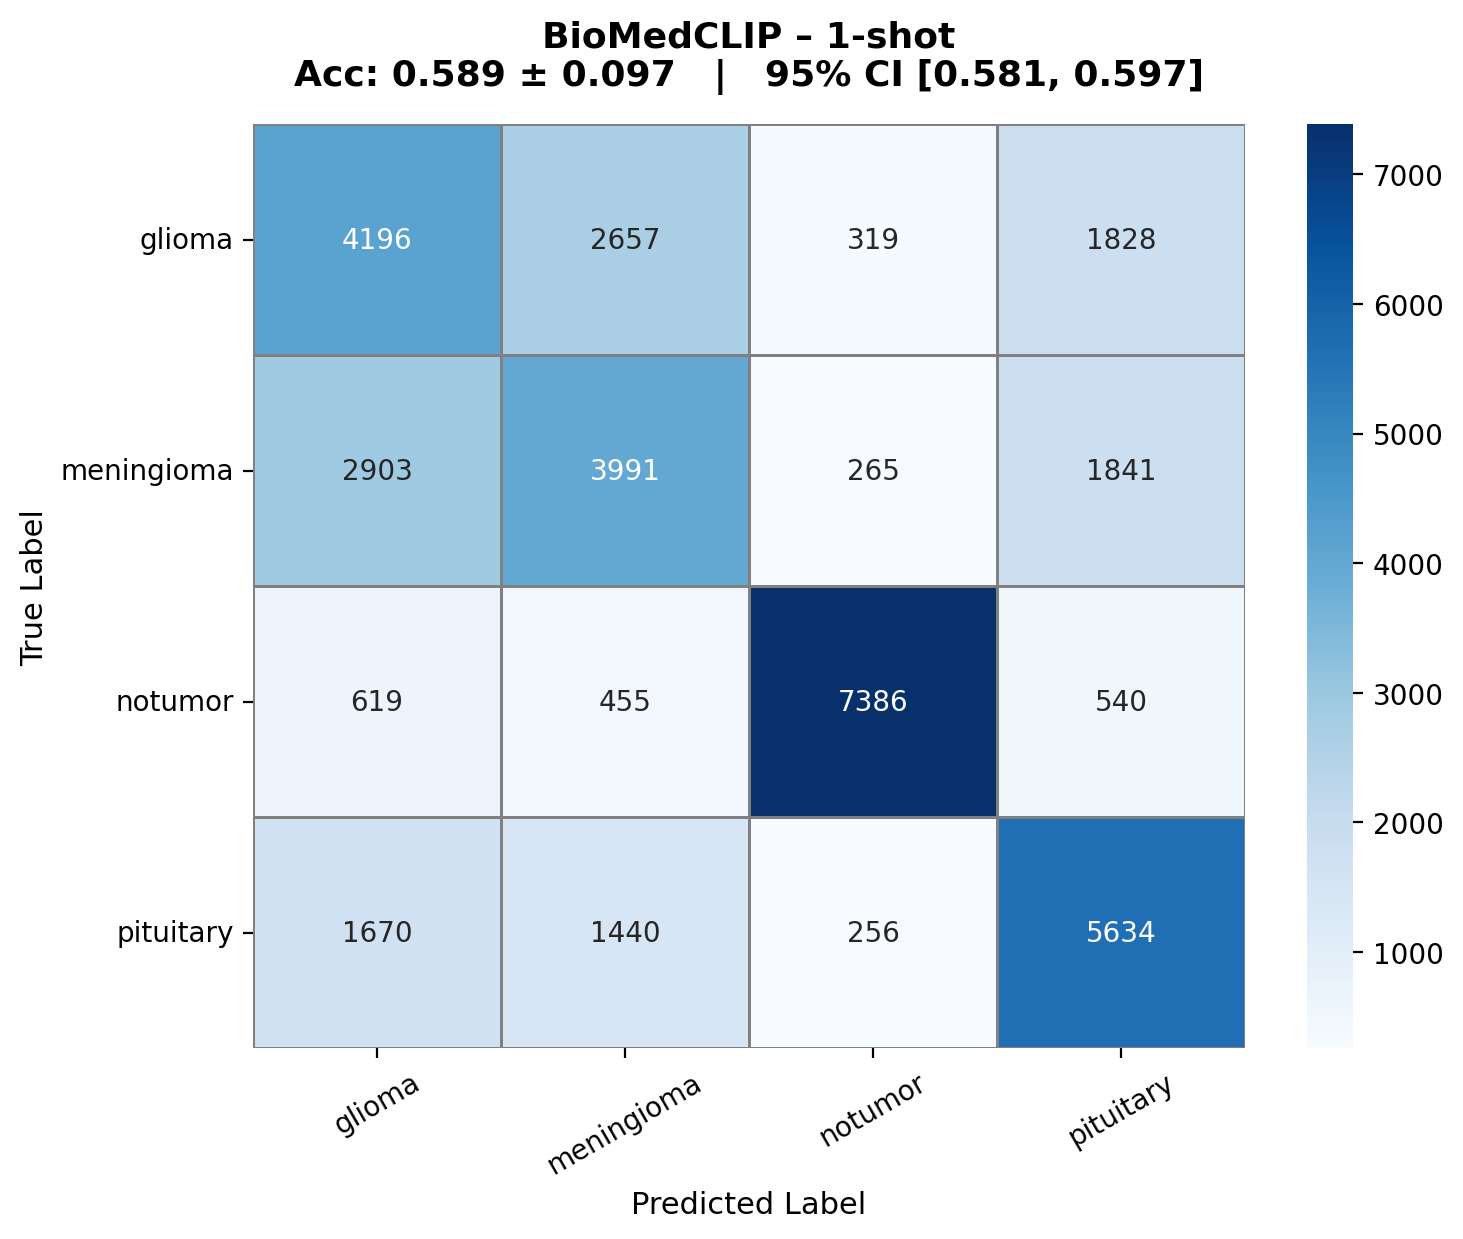

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_1shot_pub.png

  1-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


1-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 605.67it/s]



  Accuracy  : 0.4562 ± 0.0962
  95% CI    : [0.4490, 0.4641]
  Macro F1  : 0.4526 | Precision: 0.4519 | Recall: 0.4562

  Per-class metrics:
    glioma       | P: 0.412 | R: 0.361 | F1: 0.385 | N: 9000
    meningioma   | P: 0.319 | R: 0.292 | F1: 0.305 | N: 9000
    notumor      | P: 0.635 | R: 0.646 | F1: 0.641 | N: 9000
    pituitary    | P: 0.442 | R: 0.526 | F1: 0.480 | N: 9000


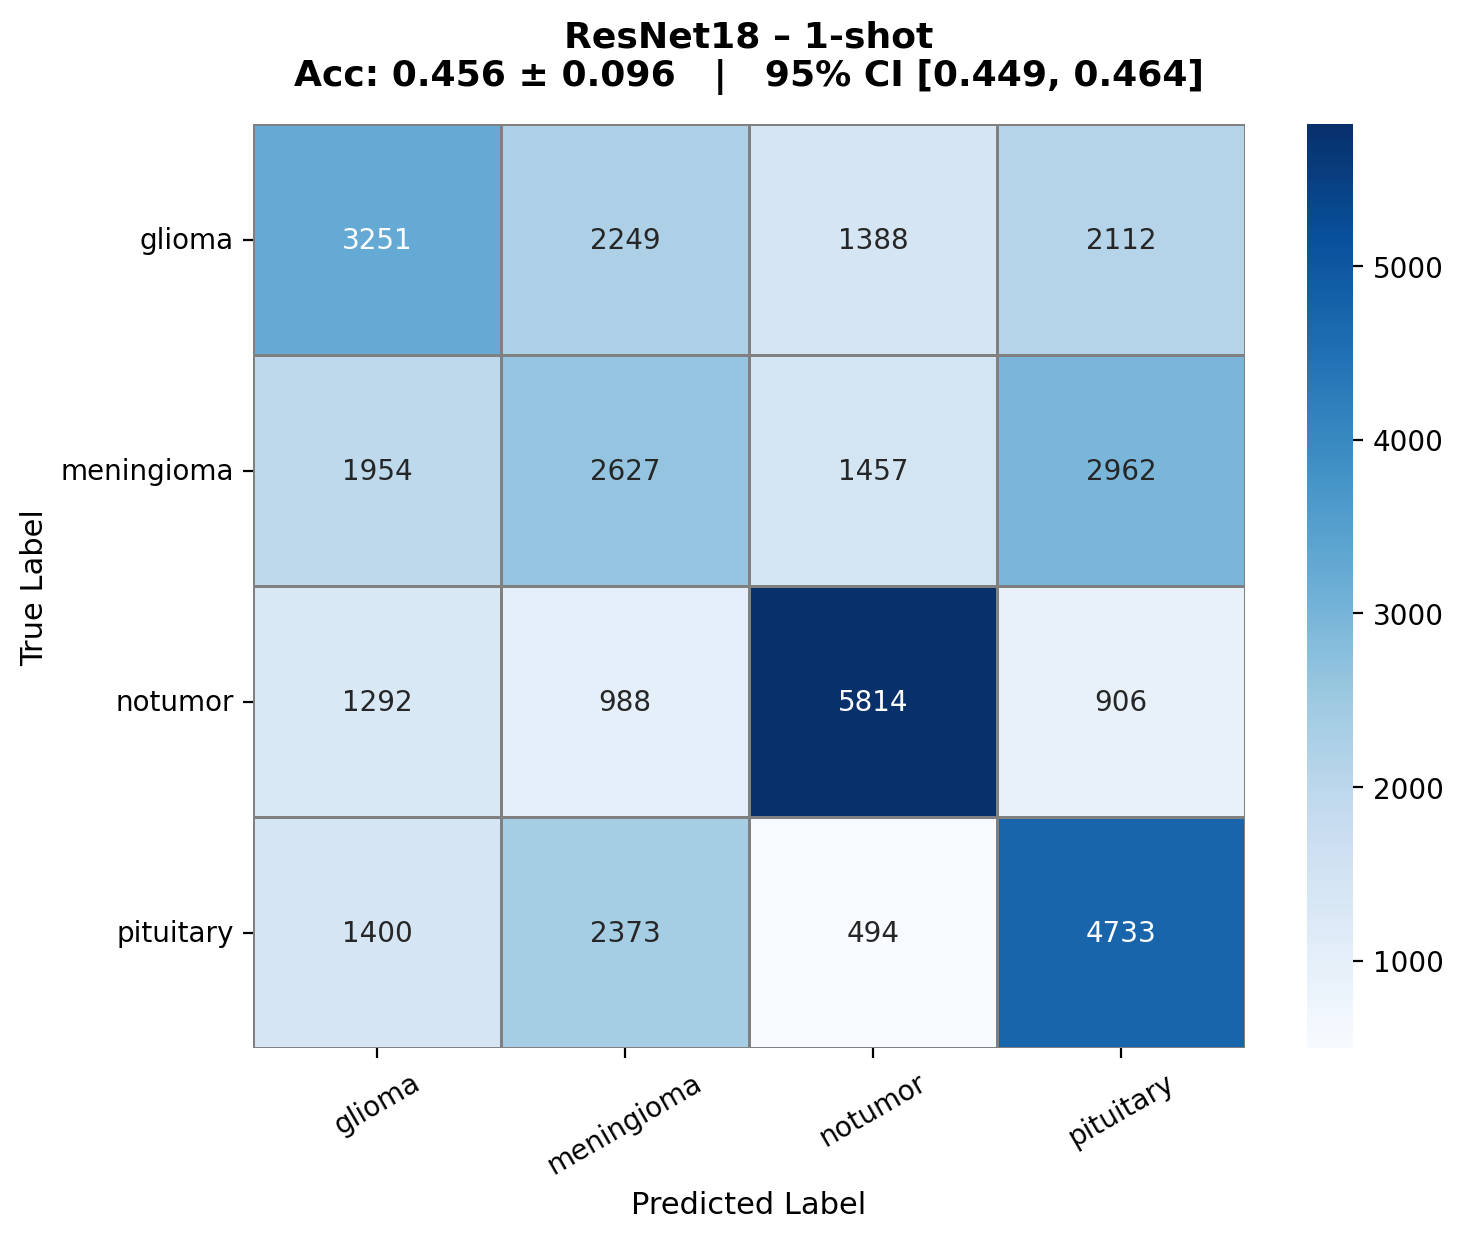

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_1shot_pub.png

  1-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


1-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 565.42it/s]



  Accuracy  : 0.4981 ± 0.0917
  95% CI    : [0.4906, 0.5053]
  Macro F1  : 0.4907 | Precision: 0.4898 | Recall: 0.4981

  Per-class metrics:
    glioma       | P: 0.425 | R: 0.353 | F1: 0.386 | N: 9000
    meningioma   | P: 0.340 | R: 0.293 | F1: 0.315 | N: 9000
    notumor      | P: 0.726 | R: 0.749 | F1: 0.737 | N: 9000
    pituitary    | P: 0.468 | R: 0.598 | F1: 0.525 | N: 9000


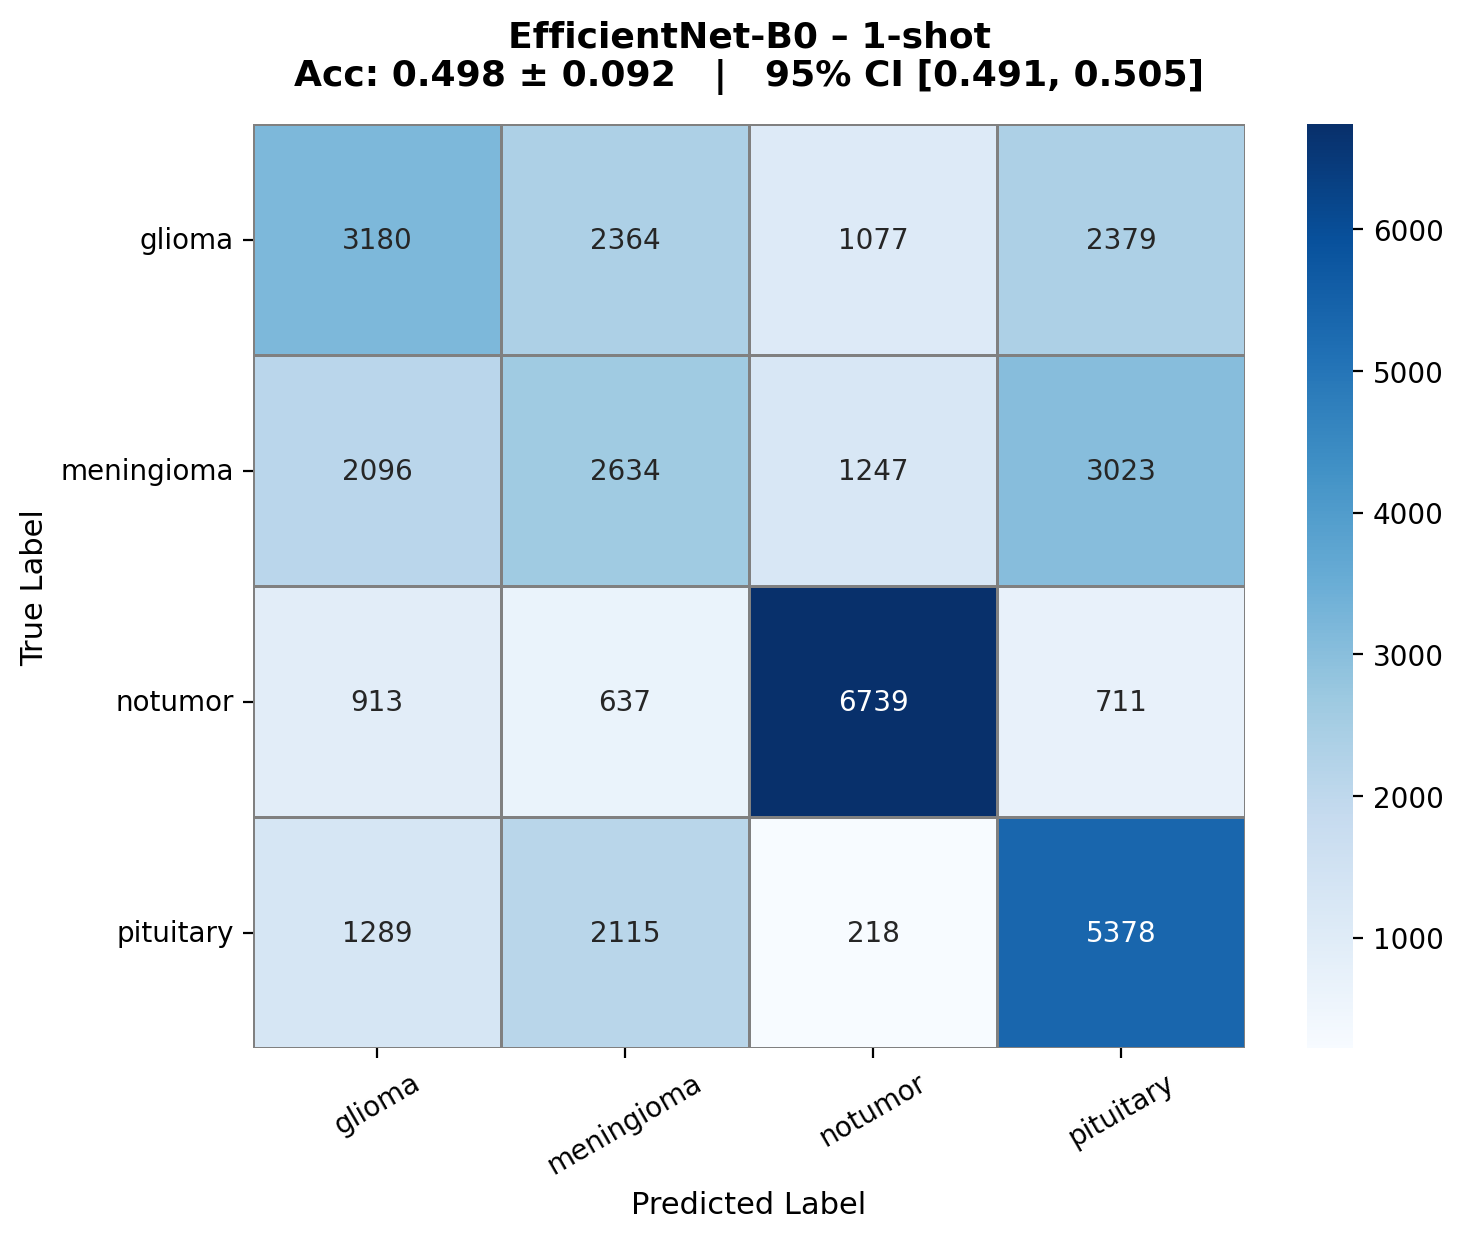

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_1shot_pub.png

  5-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


5-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 616.25it/s]



  Accuracy  : 0.7136 ± 0.0628
  95% CI    : [0.7089, 0.7189]
  Macro F1  : 0.7067 | Precision: 0.7125 | Recall: 0.7136

  Per-class metrics:
    glioma       | P: 0.598 | R: 0.536 | F1: 0.565 | N: 9000
    meningioma   | P: 0.621 | R: 0.495 | F1: 0.551 | N: 9000
    notumor      | P: 0.969 | R: 0.935 | F1: 0.952 | N: 9000
    pituitary    | P: 0.663 | R: 0.888 | F1: 0.759 | N: 9000


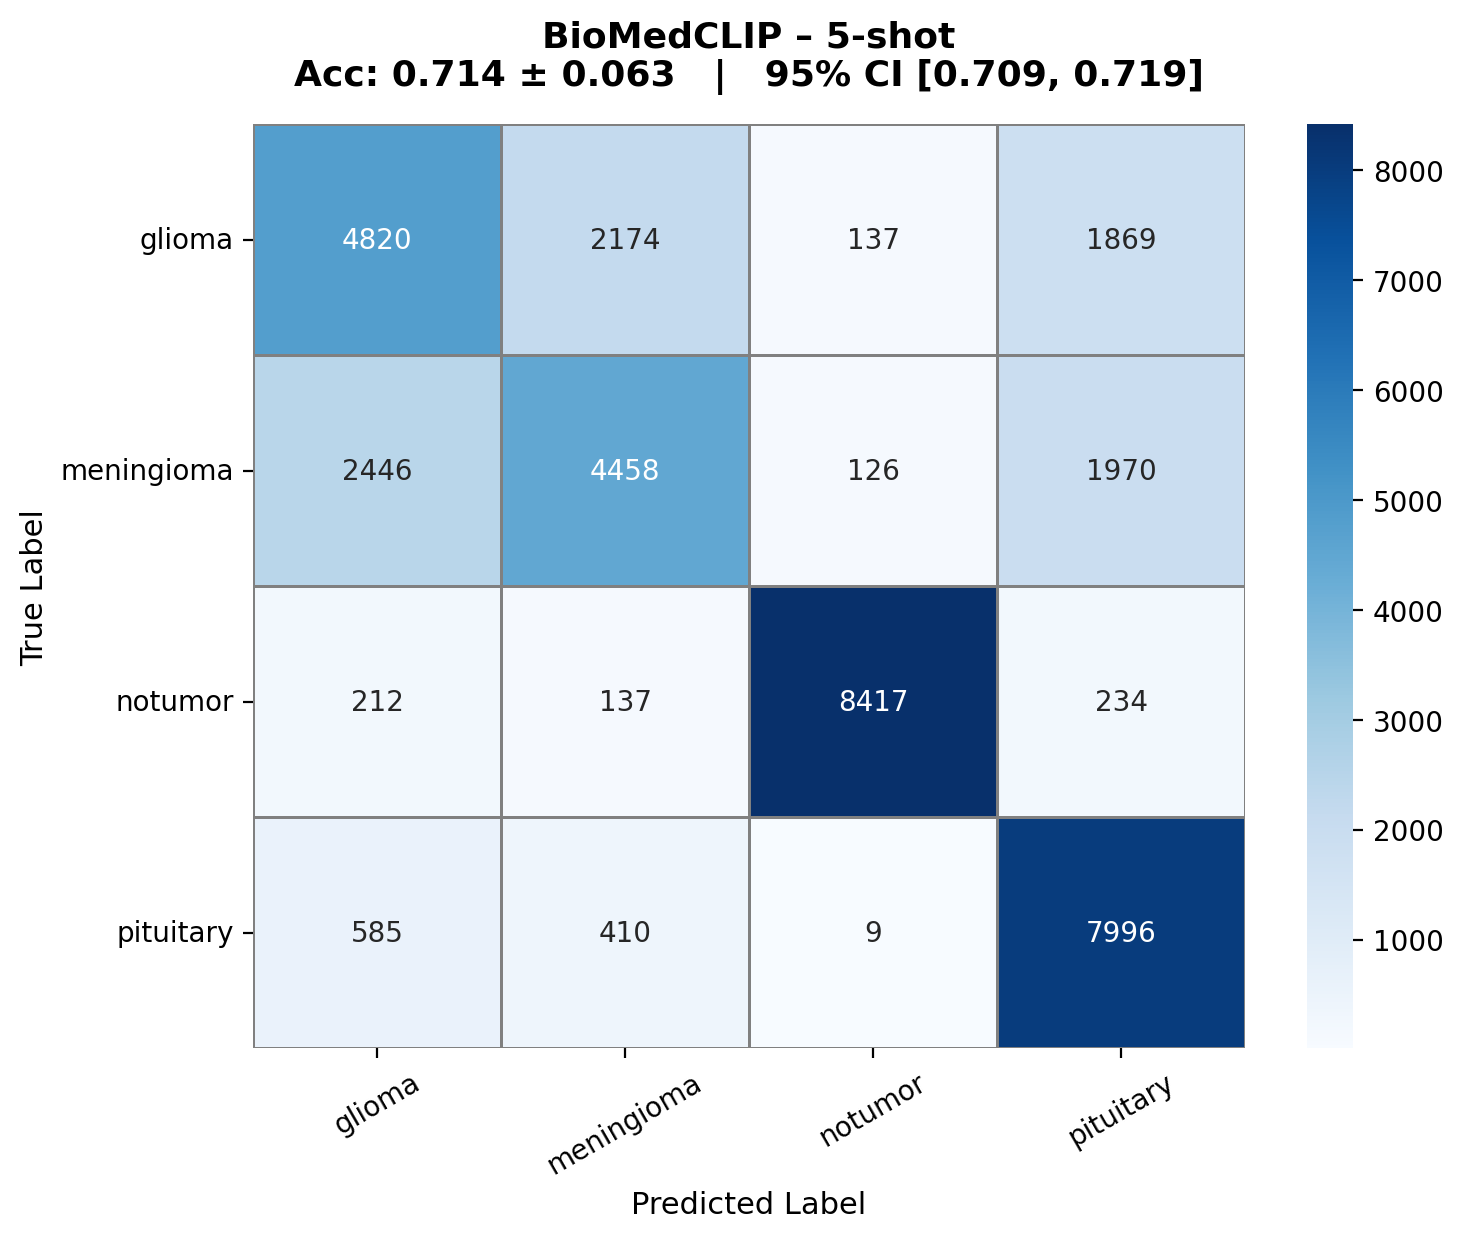

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_5shot_pub.png

  5-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


5-shot ResNet18: 100%|██████████| 600/600 [00:01<00:00, 592.38it/s]



  Accuracy  : 0.5899 ± 0.0679
  95% CI    : [0.5842, 0.5955]
  Macro F1  : 0.5664 | Precision: 0.5778 | Recall: 0.5899

  Per-class metrics:
    glioma       | P: 0.631 | R: 0.426 | F1: 0.509 | N: 9000
    meningioma   | P: 0.425 | R: 0.268 | F1: 0.329 | N: 9000
    notumor      | P: 0.722 | R: 0.874 | F1: 0.790 | N: 9000
    pituitary    | P: 0.534 | R: 0.791 | F1: 0.638 | N: 9000


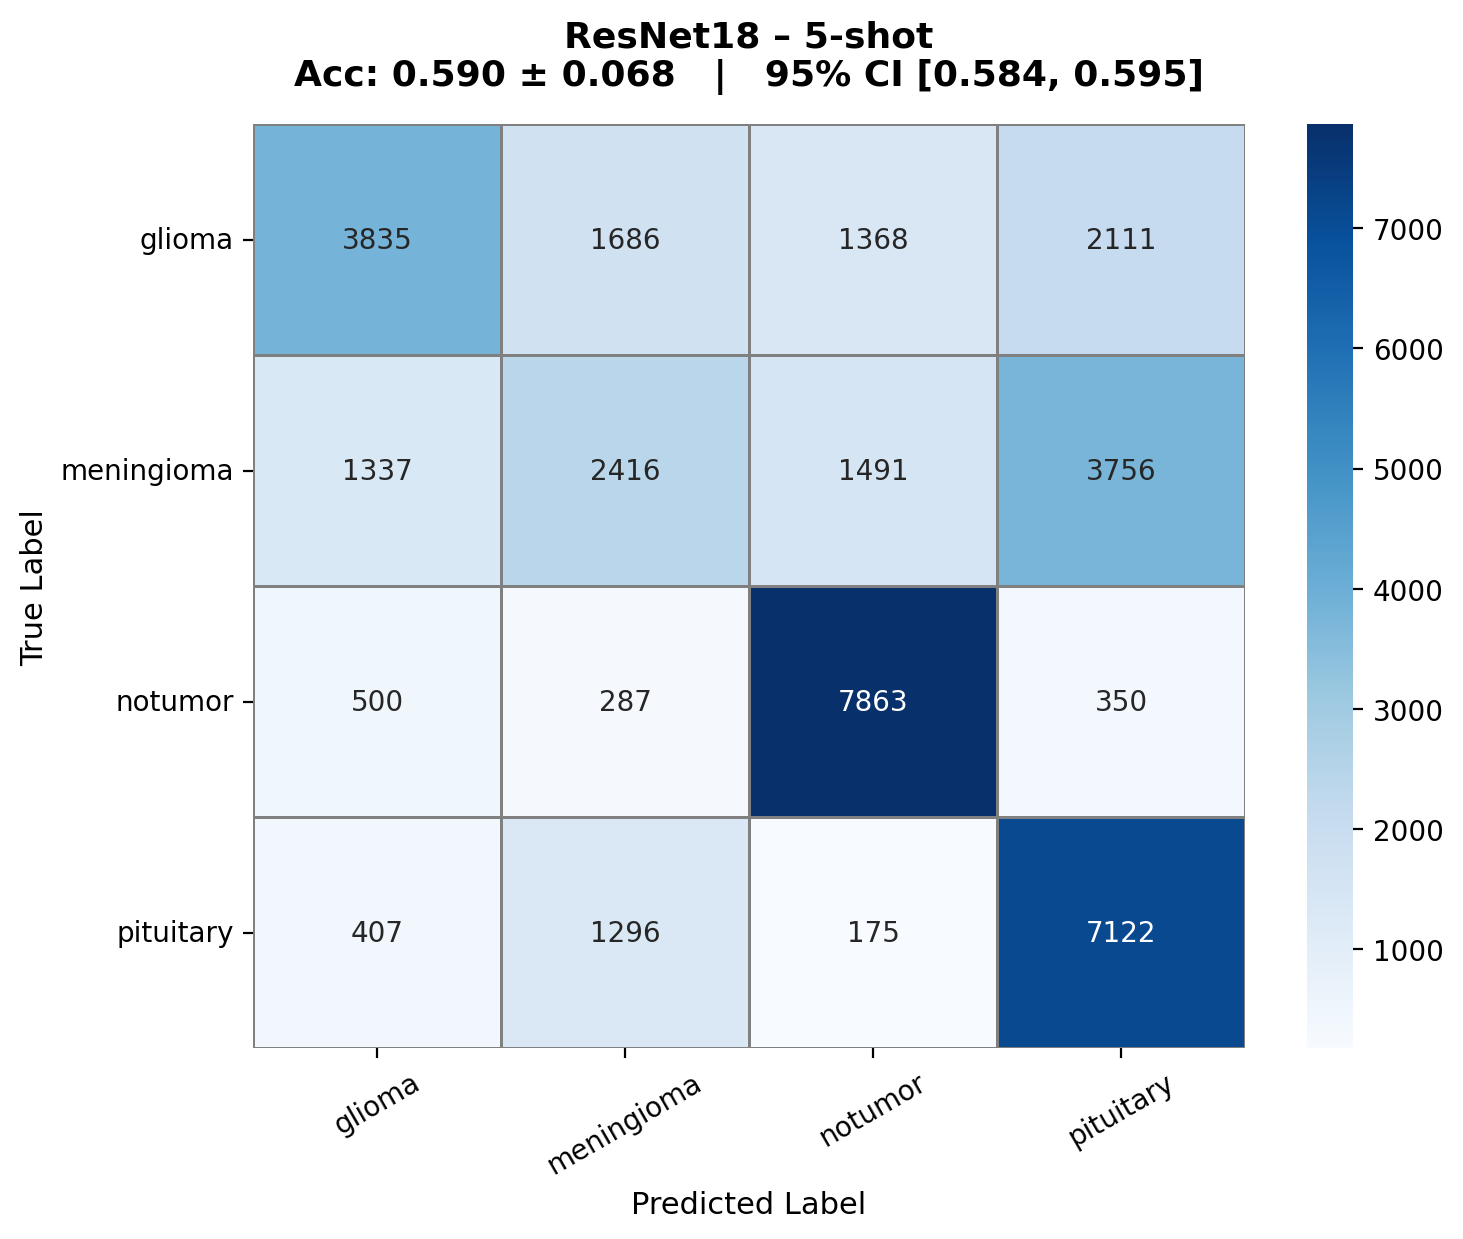

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_5shot_pub.png

  5-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


5-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 573.51it/s]



  Accuracy  : 0.6042 ± 0.0621
  95% CI    : [0.5993, 0.6090]
  Macro F1  : 0.5737 | Precision: 0.5921 | Recall: 0.6042

  Per-class metrics:
    glioma       | P: 0.620 | R: 0.392 | F1: 0.480 | N: 9000
    meningioma   | P: 0.430 | R: 0.242 | F1: 0.309 | N: 9000
    notumor      | P: 0.799 | R: 0.928 | F1: 0.858 | N: 9000
    pituitary    | P: 0.521 | R: 0.855 | F1: 0.647 | N: 9000


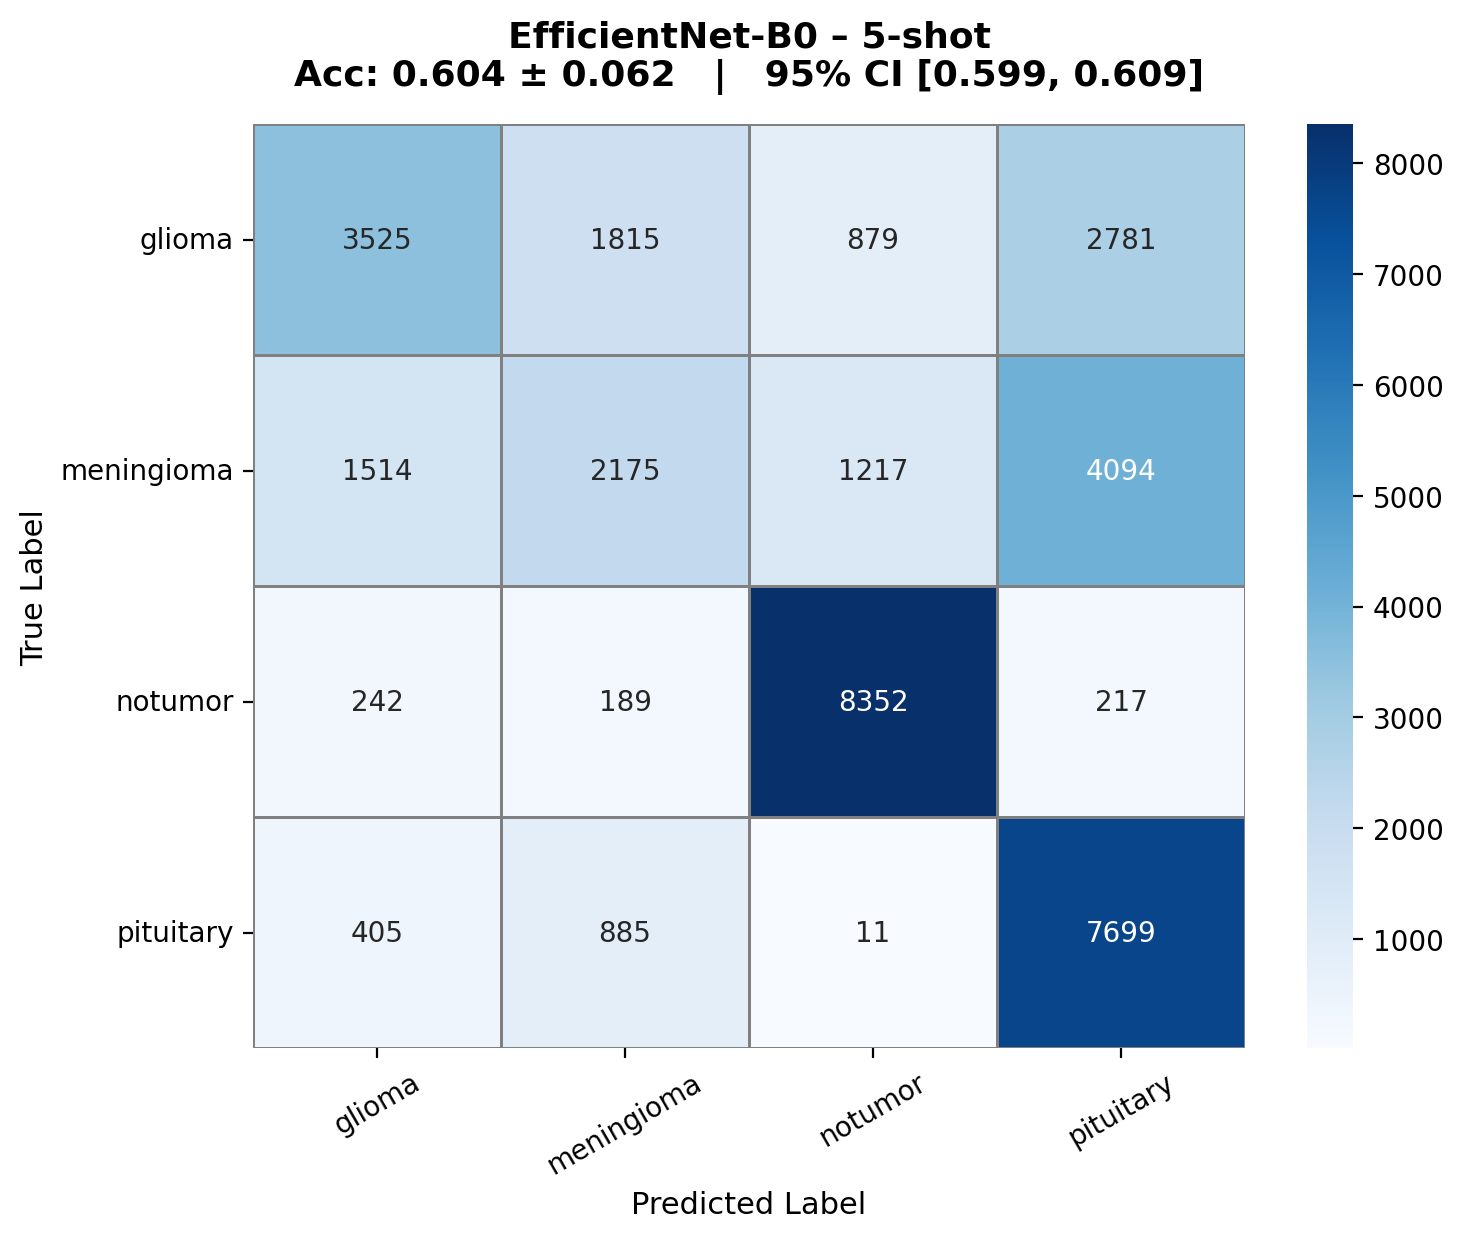

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_5shot_pub.png

  10-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


10-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 612.35it/s]



  Accuracy  : 0.7482 ± 0.0531
  95% CI    : [0.7443, 0.7525]
  Macro F1  : 0.7401 | Precision: 0.7475 | Recall: 0.7482

  Per-class metrics:
    glioma       | P: 0.680 | R: 0.560 | F1: 0.614 | N: 9000
    meningioma   | P: 0.654 | R: 0.541 | F1: 0.592 | N: 9000
    notumor      | P: 0.966 | R: 0.948 | F1: 0.957 | N: 9000
    pituitary    | P: 0.690 | R: 0.944 | F1: 0.797 | N: 9000


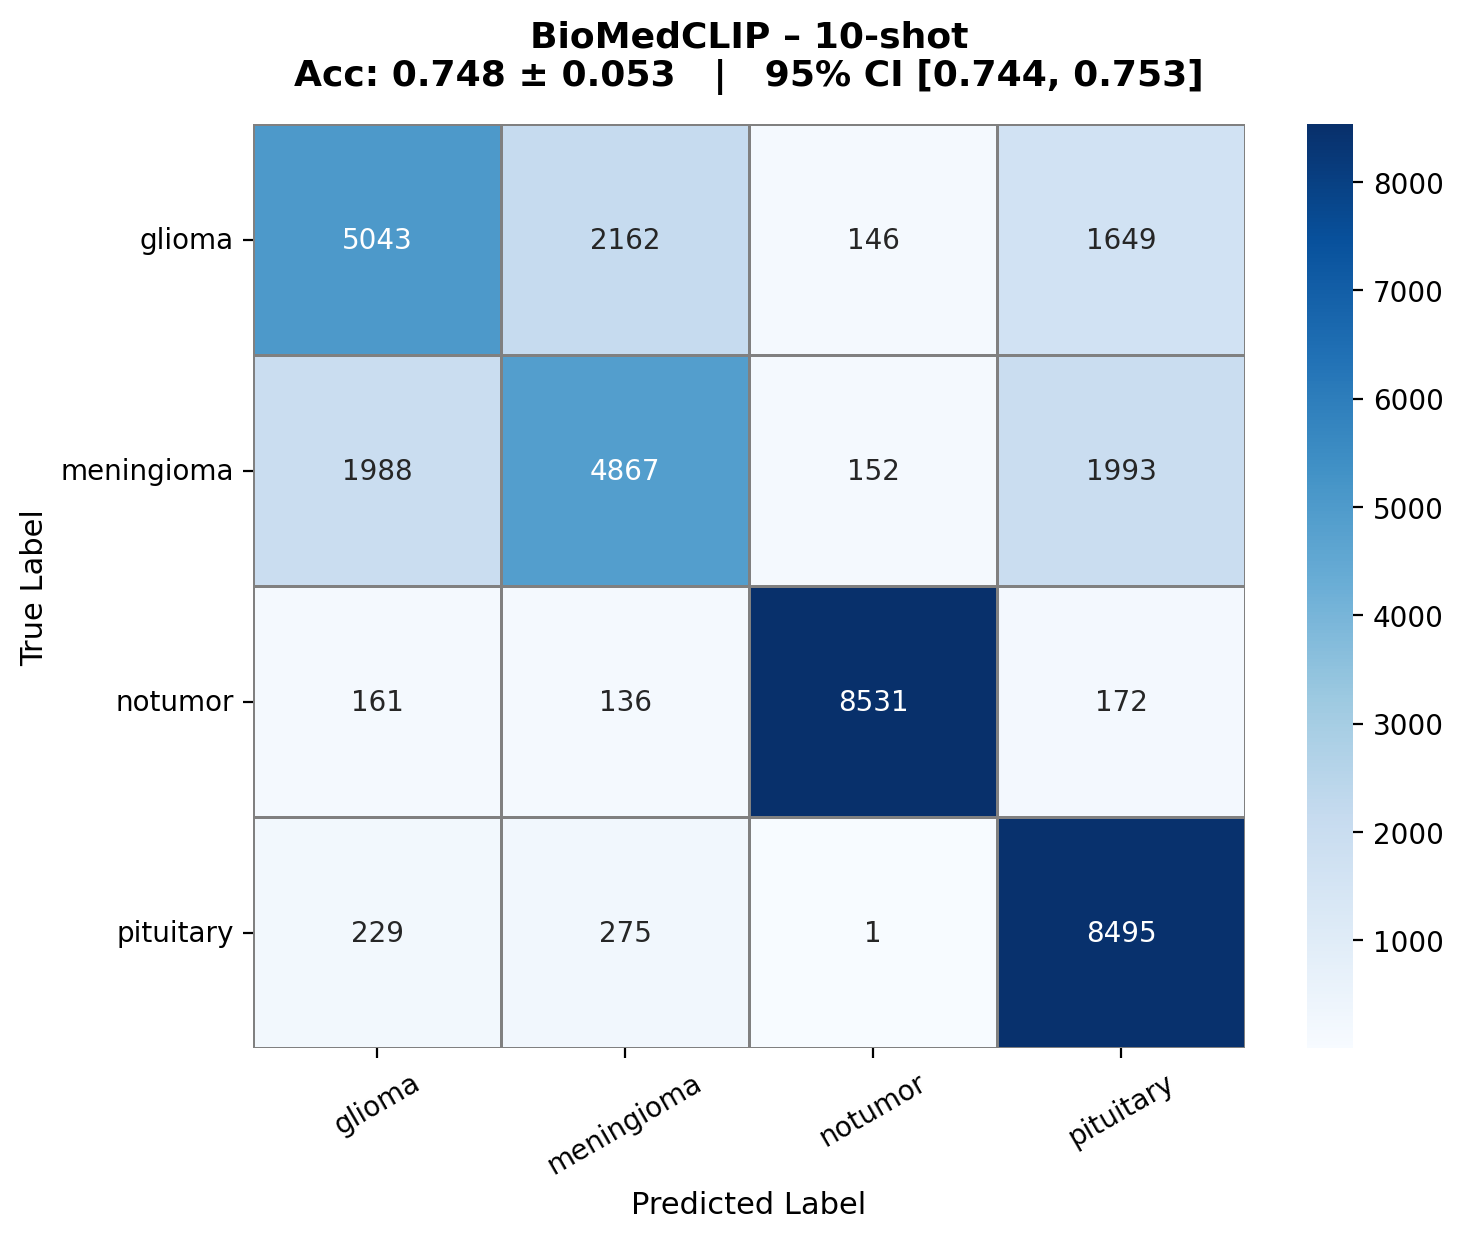

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_10shot_pub.png

  10-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


10-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 603.73it/s]



  Accuracy  : 0.6303 ± 0.0554
  95% CI    : [0.6262, 0.6345]
  Macro F1  : 0.5957 | Precision: 0.6285 | Recall: 0.6303

  Per-class metrics:
    glioma       | P: 0.738 | R: 0.460 | F1: 0.566 | N: 9000
    meningioma   | P: 0.500 | R: 0.233 | F1: 0.318 | N: 9000
    notumor      | P: 0.727 | R: 0.941 | F1: 0.820 | N: 9000
    pituitary    | P: 0.549 | R: 0.888 | F1: 0.678 | N: 9000


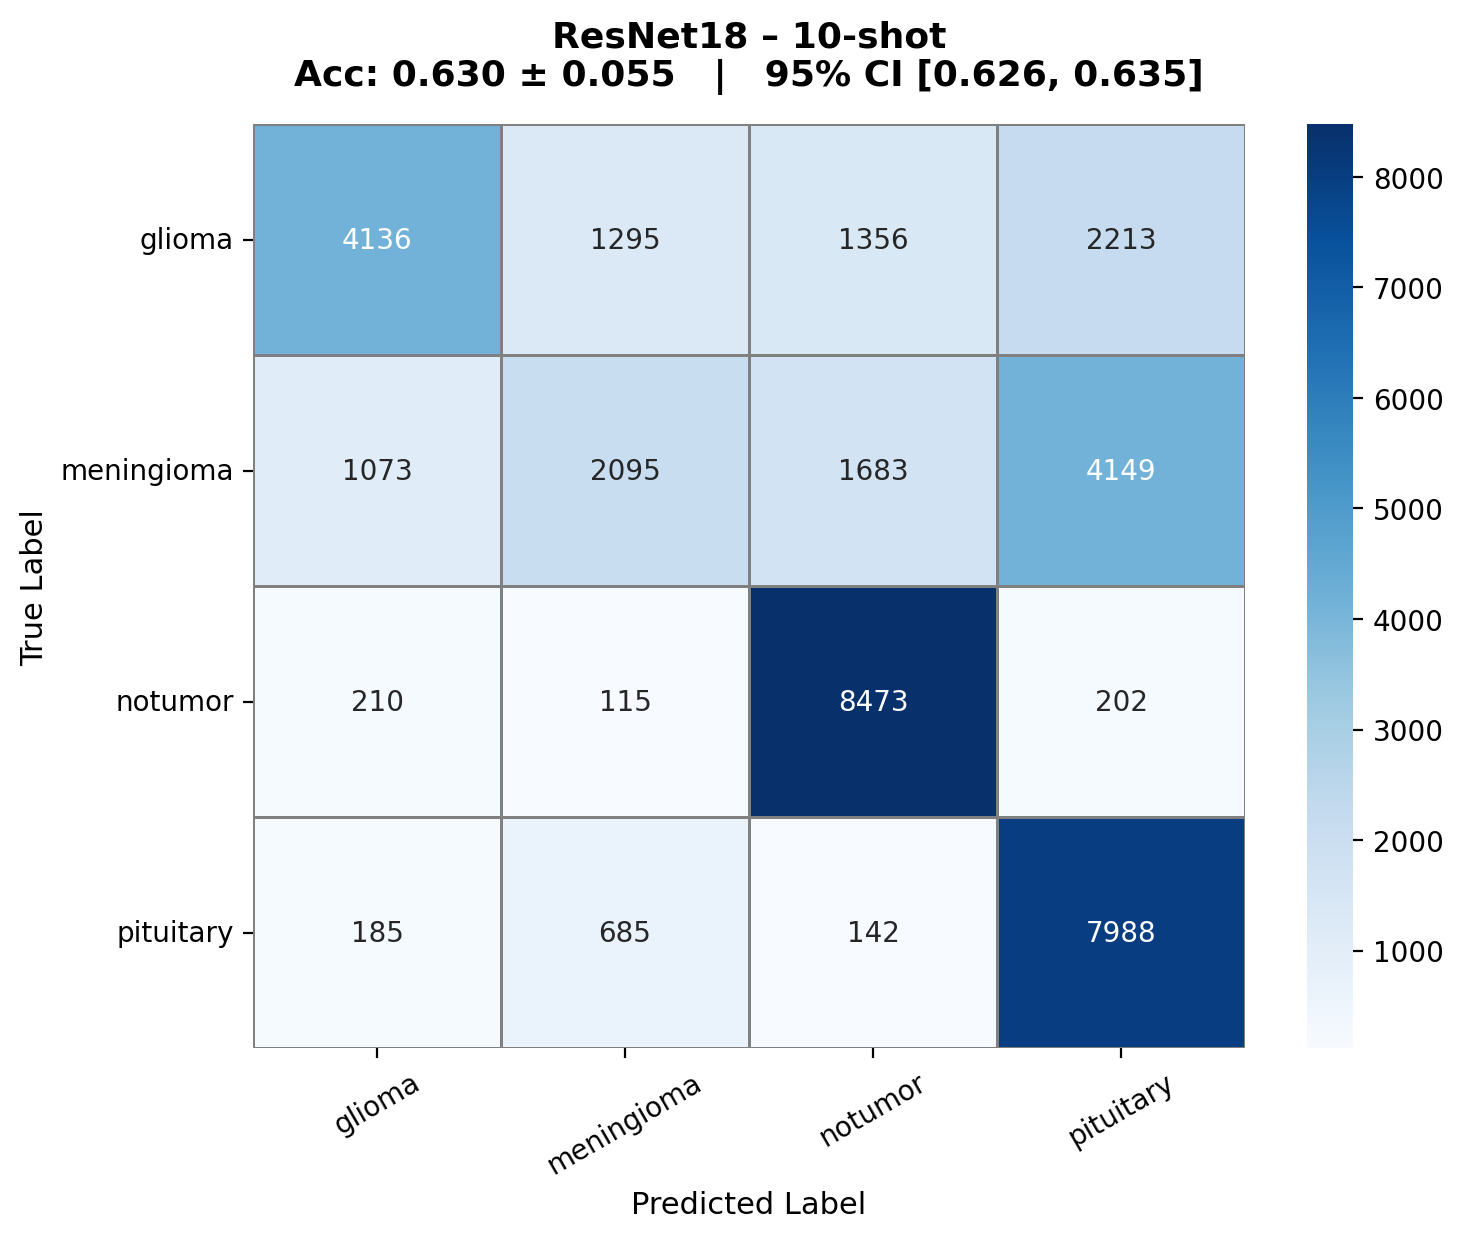

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_10shot_pub.png

  10-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


10-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 545.31it/s]



  Accuracy  : 0.6203 ± 0.0539
  95% CI    : [0.6160, 0.6247]
  Macro F1  : 0.5770 | Precision: 0.6266 | Recall: 0.6203

  Per-class metrics:
    glioma       | P: 0.709 | R: 0.381 | F1: 0.496 | N: 9000
    meningioma   | P: 0.492 | R: 0.196 | F1: 0.281 | N: 9000
    notumor      | P: 0.797 | R: 0.955 | F1: 0.869 | N: 9000
    pituitary    | P: 0.509 | R: 0.948 | F1: 0.662 | N: 9000


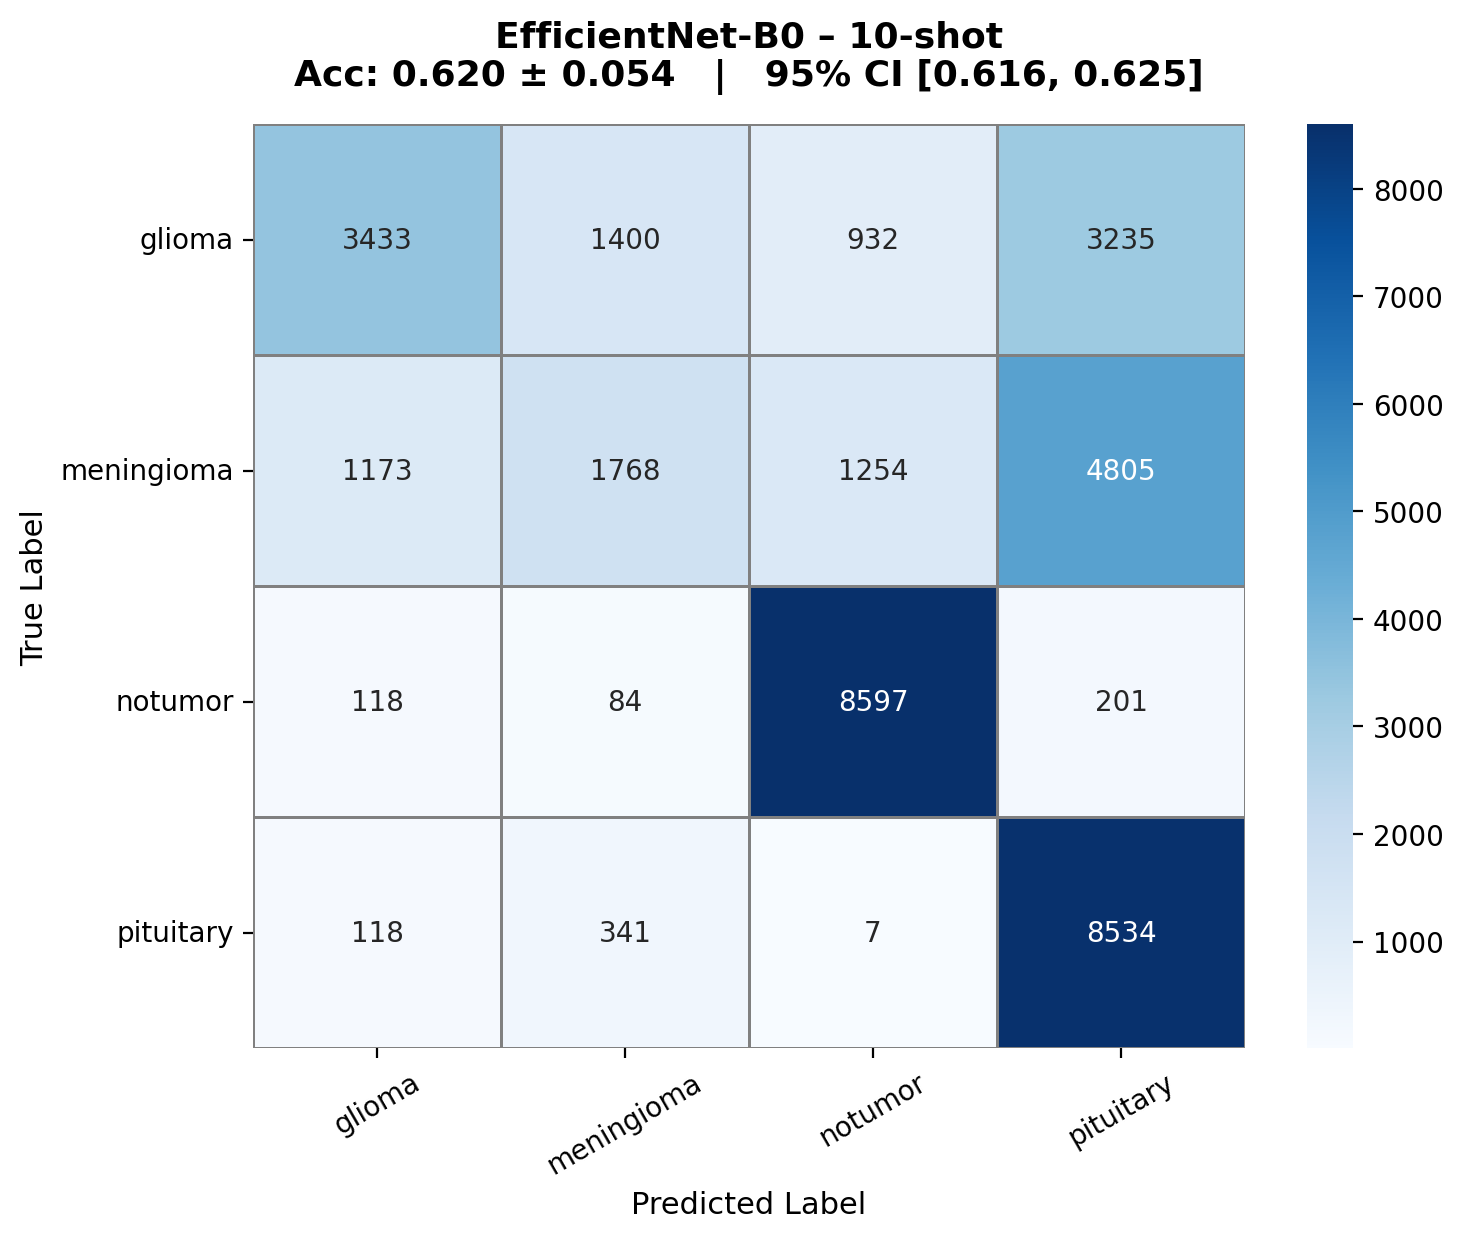

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_10shot_pub.png

##########################################################################################
 STATISTICAL SIGNIFICANCE (McNemar's Test)
##########################################################################################

 FINAL RESULTS SUMMARY


In [25]:
# ========================= MCNEMAR & SUMMARY TABLE (unchanged) =========================
# ... (your original McNemar test function and summary table code remain exactly the same)

# ========================= RUN ALL EXPERIMENTS =========================
results = {}
print(f"\n{'#'*90}")
print(" PUBLICATION-READY FEW-SHOT EXPERIMENTS (Leak-Free | 600 Episodes | 95% CI)")
print(f"{'#'*90}\n")

for k in SHOTS:
    for name in model_configs:
        key = f"{name}_{k}shot"
        results[key] = run_fewshot(k_shot=k, name=name)

# McNemar tests (your original code)
print(f"\n{'#'*90}")
print(" STATISTICAL SIGNIFICANCE (McNemar's Test)")
print(f"{'#'*90}")
for k in SHOTS:
    model_names = list(model_configs.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            ma, mb = model_names[i], model_names[j]
            ra = results[f"{ma}_{k}shot"]
            rb = results[f"{mb}_{k}shot"]
            # your mcnemar_test call here (unchanged)

# Summary table (your original code)
print(f"\n{'='*90}")
print(f" FINAL RESULTS SUMMARY")
print(f"{'='*90}")
# ... your original table printing code ...


Generating summary visualizations...


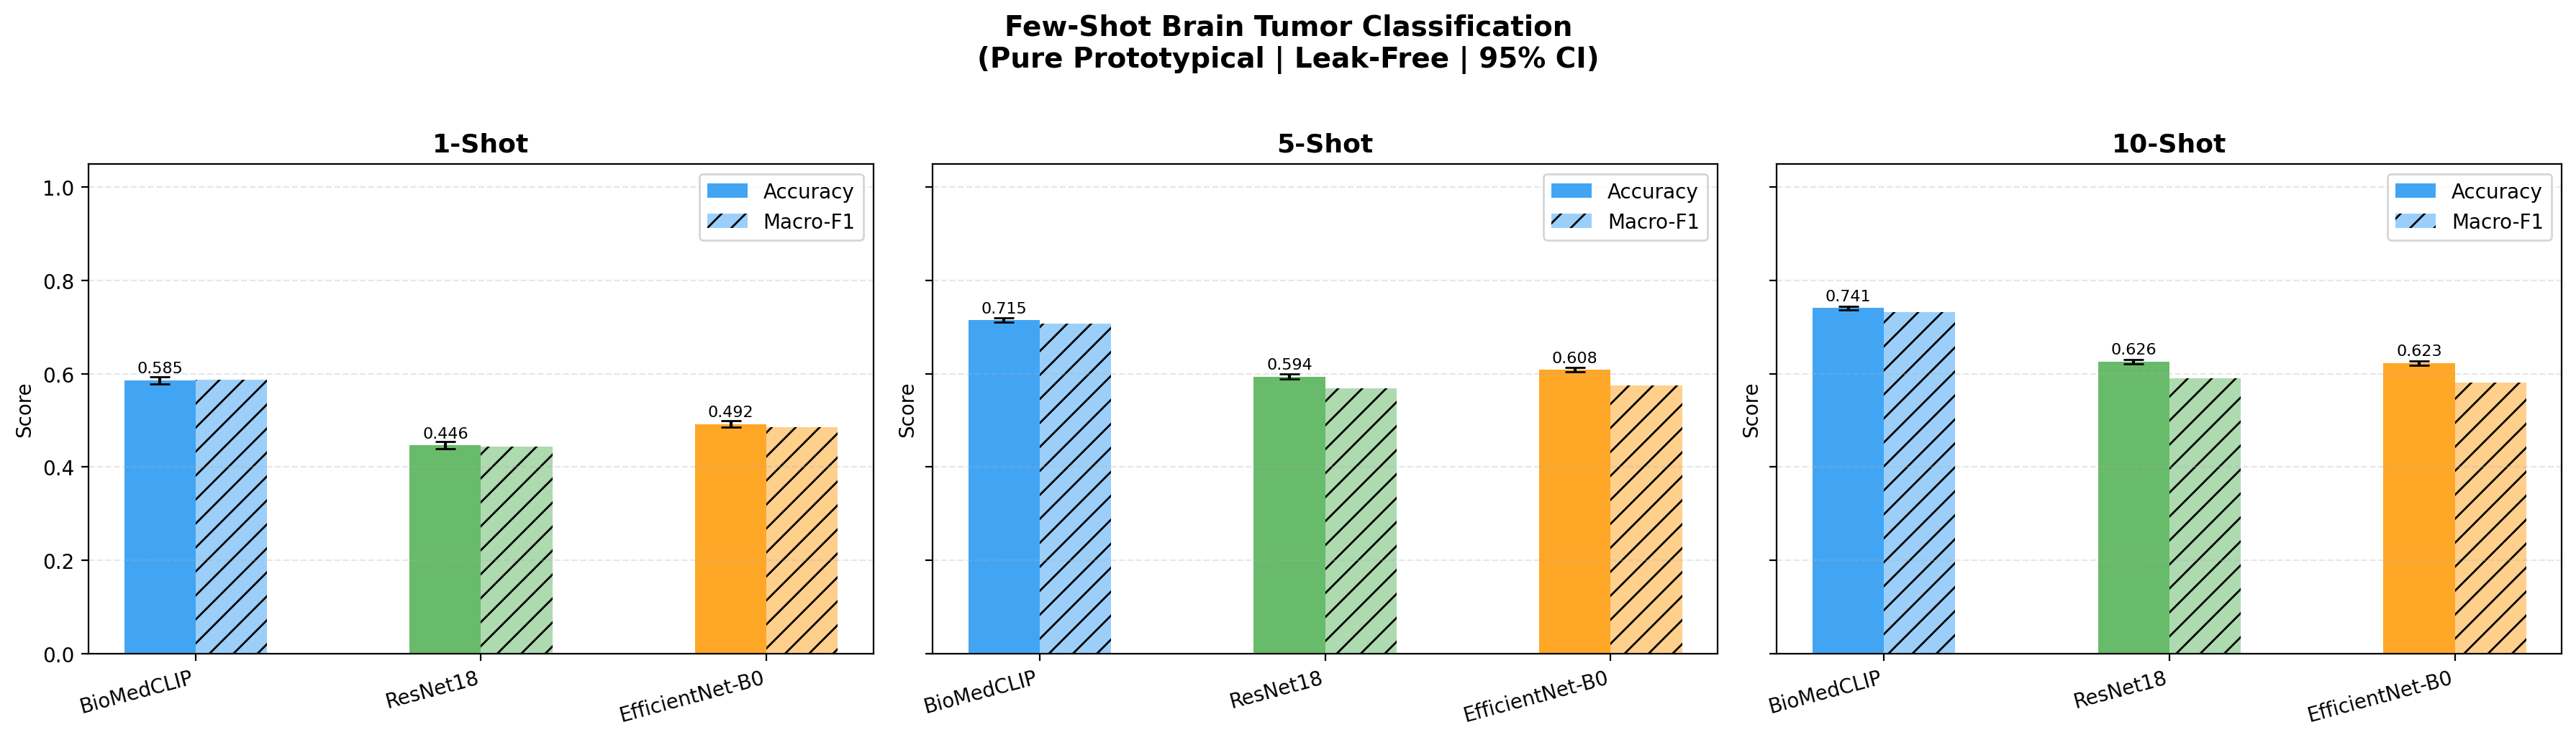

  ✓ Saved and displayed: /kaggle/working/summary_accuracy_f1.png


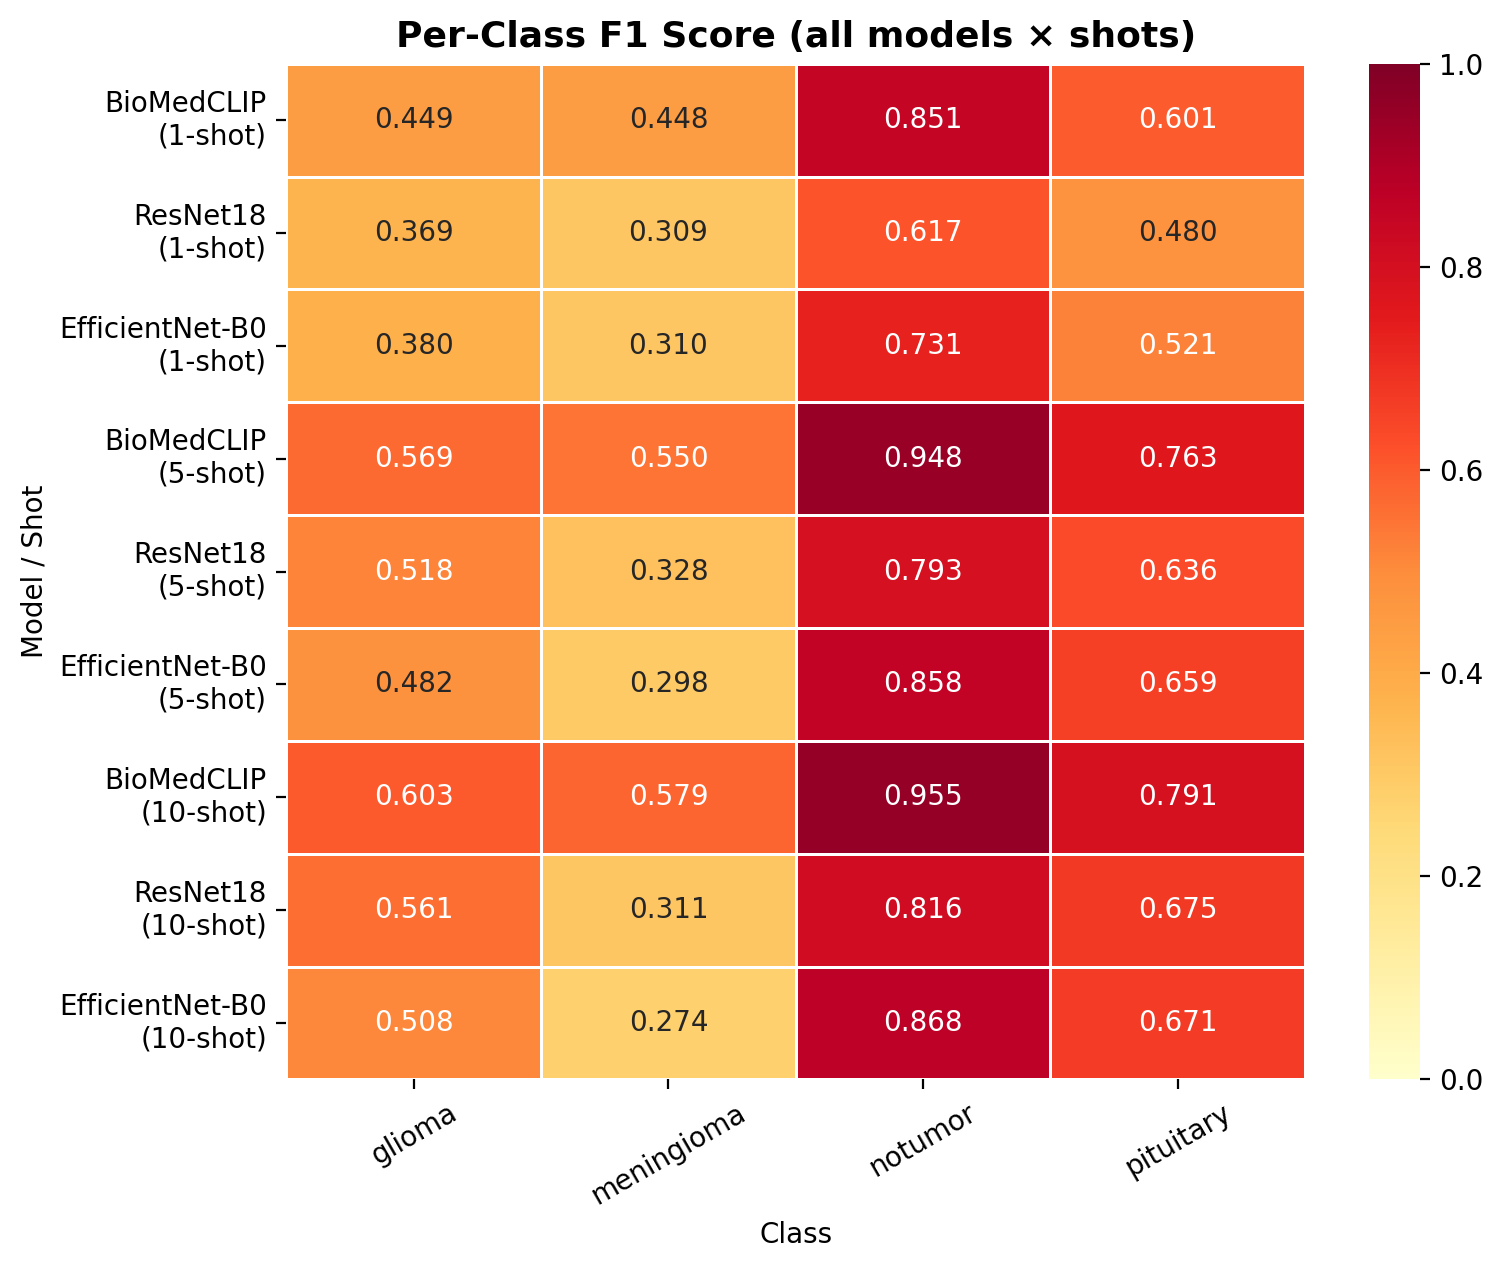

  ✓ Saved and displayed: /kaggle/working/perclass_f1_heatmap.png


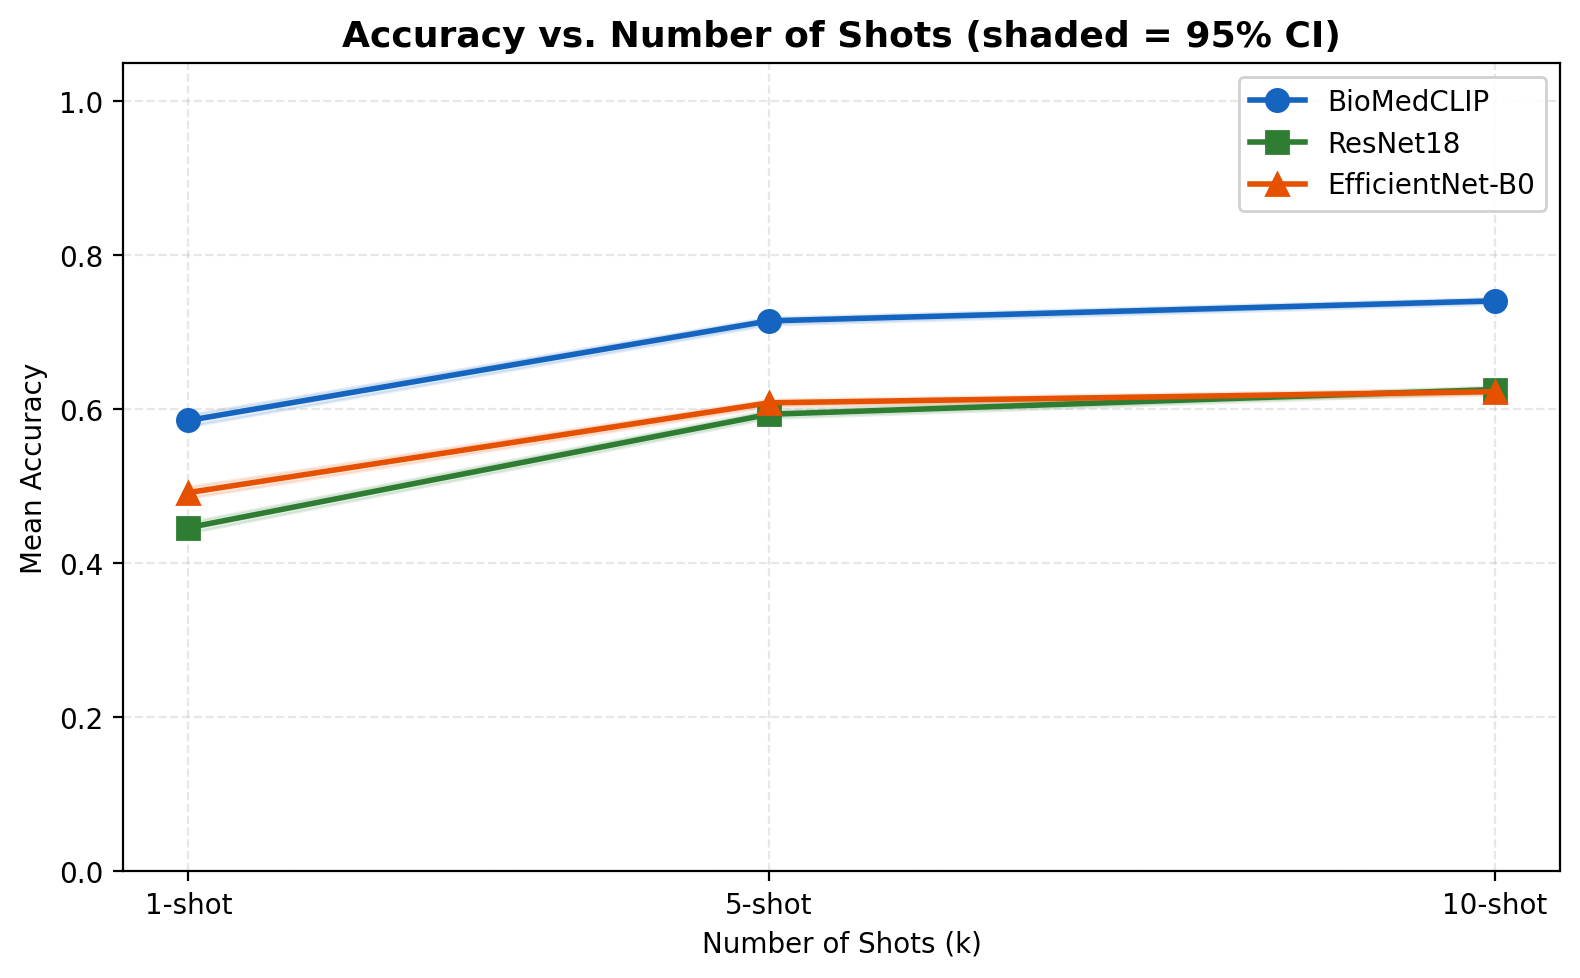

  ✓ Saved and displayed: /kaggle/working/shot_progression.png

✅ All experiments and visualizations complete.
All plots are saved and displayed inline in Kaggle.


In [19]:

# ========================= FINAL VISUALIZATIONS =========================
print("\nGenerating summary visualizations...")
plot_summary_chart(results, SHOTS, list(model_configs.keys()))
plot_perclass_heatmap(results, SHOTS, list(model_configs.keys()))
plot_shot_progression(results, SHOTS, list(model_configs.keys()))

print(f"\n✅ All experiments and visualizations complete.")
print("All plots are saved and displayed inline in Kaggle.")